# Week 2 – Occupation Filtering and Final Selection

## Objective

The objective of this notebook is to identify occupations with sufficient labour-market demand for detailed analysis.

Occupations are selected based on:

- Job posting frequency
- Labour-market relevance
- Clear occupational definitions (NOC)
- Sufficient observations for statistical analysis
- Suitability for later predictive modelling

The final occupation list will be used throughout Week 3 and the remaining stages of the capstone project.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

In [49]:
# Define project paths

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Users\Admin\Capstone_Project"
)

CLEAN_FILE = (
    PROJECT_ROOT /
    "Data" /
    "Processed" /
    "job_bank_preliminary_clean.csv"
)

TABLES = (
    PROJECT_ROOT /
    "Outputs" /
    "Tables"
)

FIGURES = (
    PROJECT_ROOT /
    "Outputs" /
    "Figures"
)

TABLES.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

# Load cleaned Job Bank dataset

df = pd.read_csv(
    CLEAN_FILE,
    low_memory=False
)

print(
    "Dataset Shape:",
    df.shape
)

df.head()

Dataset Shape: (55091, 66)


,posting_id,job_title,original_job_title,noc_2016_code,noc_2016_name,noc_2021_code,noc_2021_name,external_indicator,posting_date,vacancy_count,...,salary_condition_other_benefits,commission_per,commission_type,hours_per,hours_minimum,hours_maximum,work_hours,work_hours_from_time,work_hours_to_time,salary_average
0,15645194,Facilities and Fleet Maintenance Support,NaN,NaN,NaN,NaN,NaN,1,2026-06-17,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,29.20
1,15675531,sales associate,Part Time Sales Associate-SoftMoc ShoeRack Cro...,6421.0,Retail salespersons,64100.0,Retail salespersons and visual merchandisers,1,2026-06-29,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,16.25
2,15597307,"testing, adjusting and balancing (tab) technic...",HVAC R & Gasfitter Journeymen Apprentice (Leve...,2232.0,Mechanical engineering technologists and techn...,11201.0,Professional occupations in business managemen...,1,2026-06-01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,50.00
3,15621351,"chartered professional accountant, chartered a...",NaN,1111.0,Financial auditors and accountants,11100.0,Financial auditors and accountants,0,2026-06-09,1,...,No,NaN,NaN,Week,4.0,10.0,No,NaN,NaN,65.00
4,15629538,refrigeration technician,NaN,7313.0,Refrigeration and air conditioning mechanics,72402.0,"Heating, refrigeration and air conditioning me...",1,2026-06-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,41.50


In [5]:
# Review dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55091 entries, 0 to 55090
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   posting_id                        55091 non-null  int64  
 1   job_title                         55091 non-null  object 
 2   original_job_title                21354 non-null  object 
 3   noc_2016_code                     54716 non-null  float64
 4   noc_2016_name                     54716 non-null  object 
 5   noc_2021_code                     54721 non-null  float64
 6   noc_2021_name                     54721 non-null  object 
 7   external_indicator                55091 non-null  int64  
 8   posting_date                      55091 non-null  object 
 9   vacancy_count                     55091 non-null  int64  
 10  official_language                 55091 non-null  object 
 11  education_level                   21979 non-null  object 
 12  expe

In [7]:
# Create occupation-level labour market summary

occupation_summary = (
    df.groupby(
        [
            "job_title",
            "noc_2021_code",
            "noc_2021_name"
        ]
    )
    .agg(
        Posting_Count=("posting_id", "count"),
        Vacancy_Count=("vacancy_count", "sum")
    )
    .reset_index()
)

occupation_summary = occupation_summary.sort_values(
    by="Posting_Count",
    ascending=False
)

occupation_summary.head(20)

,job_title,noc_2021_code,noc_2021_name,Posting_Count,Vacancy_Count
1741,cook,63200.0,Cooks,1263,2233
2821,food service supervisor,62020.0,Food service supervisors,750,1716
3823,line cook,63200.0,Cooks,642,818
337,administrative assistant,13110.0,Administrative assistants,580,616
1716,continuing care assistant,33102.0,"Nurse aides, orderlies and patient service ass...",545,640
1200,carpenter,72310.0,Carpenters,486,851
5336,restaurant manager,60030.0,Restaurant and food service managers,465,560
5355,retail sales associate,64100.0,Retail salespersons and visual merchandisers,459,519
2243,"driver, truck",73300.0,Transport truck drivers,425,583
1227,cashier,65100.0,Cashiers,410,505


### Occupation Demand

Job postings were aggregated at the occupation level using NOC 2021 classifications to identify occupations with sufficient labour-market observations for further analysis.

For each occupation, our analysis calculated:

- Total number of job postings
- Total advertised vacancies

These measures were used to evaluate occupation demand and support the selection of occupations suitable for detailed diagnostic analysis and predictive modelling.

In [11]:
# Filter occupations with minimum posting threshold

filtered_occupations = occupation_summary[
    occupation_summary["Posting_Count"] >= 100
].copy()

filtered_occupations

,job_title,noc_2021_code,noc_2021_name,Posting_Count,Vacancy_Count
1741,cook,63200.0,Cooks,1263,2233
2821,food service supervisor,62020.0,Food service supervisors,750,1716
3823,line cook,63200.0,Cooks,642,818
337,administrative assistant,13110.0,Administrative assistants,580,616
1716,continuing care assistant,33102.0,"Nurse aides, orderlies and patient service ass...",545,640
...,...,...,...,...,...
2581,farm labourer - livestock,85100.0,Livestock labourers,101,146
661,"assistant manager, restaurant",60030.0,Restaurant and food service managers,101,112
4532,office manager,13100.0,Administrative officers,101,102
5607,shift manager - fast food restaurant,62020.0,Food service supervisors,101,479


In [13]:
# Check number of occupations retained after filtering

print("Number of occupations retained:", len(filtered_occupations))

Number of occupations retained: 89


### Interpretation

A minimum threshold of 100 job postings was used to reduce sparse occupations while retaining those with sufficient observations for meaningful descriptive, diagnostic, and predictive analyses.

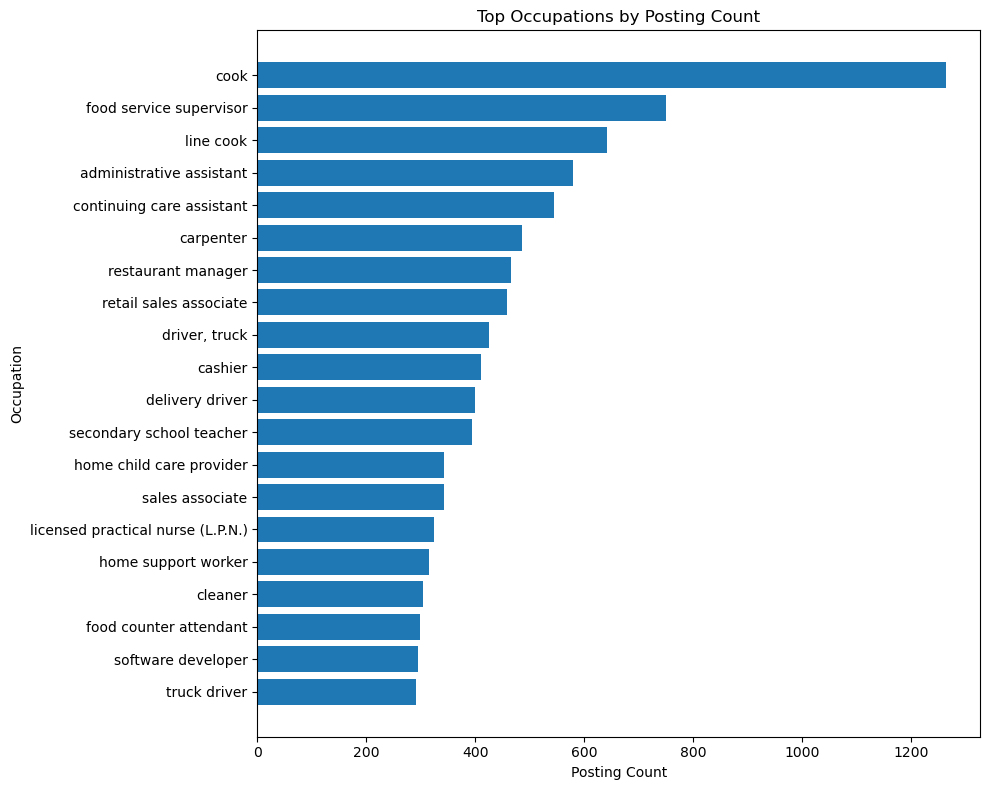

In [15]:
# Visualize top 20 occupations by posting count

top20 = filtered_occupations.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["job_title"],
    top20["Posting_Count"]
)

plt.xlabel("Posting Count")
plt.ylabel("Occupation")

plt.title("Top Occupations by Posting Count")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

Cook, Food Service Supervisor, Administrative Assistant, Continuing Care Assistant, Restaurant Manager, and Retail Sales Associate recorded the highest number of job postings in the Job Bank dataset.

High posting frequencies indicate that these occupations have strong representation in the dataset and provide sufficient observations for reliable analysis.

These occupations were identified as potential candidates for further analysis based on posting volume. Vacancy counts and labour-market relevance will also be considered during the final occupation selection process.

In [22]:
# Initial occupation shortlist selected based on:
# - Labour-market relevance
# - Posting frequency
# - Alignment with analytical objectives
# - Availability of sufficient Job Bank observations

selected_titles = [

    "software developer",

    "information technology (it) analyst",

    "administrative assistant",

    "bookkeeper",

    "office administrator",

    "office manager",

    "restaurant manager",

    "food service supervisor",

    "retail sales associate",

    "inside sales representative",

    "driver, truck",

    "delivery driver",

    "secondary school teacher",

    "continuing care assistant",

    "licensed practical nurse (l.p.n.)"

]

In [26]:
# Filter dataset for selected occupations

selected_df = df[
    df["job_title"].str.lower().isin(selected_titles)
].copy()

print(
    "Selected dataset shape:",
    selected_df.shape
)

Selected dataset shape: (5629, 66)


In [28]:
# Create final occupation summary for selected occupations

final_summary = (
    selected_df.groupby(
        [
            "job_title",
            "noc_2021_code",
            "noc_2021_name"
        ]
    )
    .agg(
        Posting_Count=("posting_id", "count"),
        Vacancy_Count=("vacancy_count", "sum")
    )
    .reset_index()
)

final_summary = final_summary.sort_values(
    by="Posting_Count",
    ascending=False
)

final_summary

,job_title,noc_2021_code,noc_2021_name,Posting_Count,Vacancy_Count
8,food service supervisor,62020.0,Food service supervisors,750,1716
3,administrative assistant,13110.0,Administrative assistants,580,616
5,continuing care assistant,33102.0,"Nurse aides, orderlies and patient service ass...",545,640
14,restaurant manager,60030.0,Restaurant and food service managers,465,560
15,retail sales associate,64100.0,Retail salespersons and visual merchandisers,459,519
7,"driver, truck",73300.0,Transport truck drivers,425,583
6,delivery driver,75201.0,Delivery service drivers and door-to-door dist...,400,412
16,secondary school teacher,41220.0,Secondary school teachers,394,395
11,licensed practical nurse (L.P.N.),32101.0,Licensed practical nurses,325,334
17,software developer,21232.0,Software developers and programmers,294,305


In [33]:
# Map selected occupations into broader labour-market sectors

sector_map = {

    "software developer":"IT / Technology",

    "information technology (it) analyst":"IT / Technology",

    "administrative assistant":"Business / Administration",

    "bookkeeper":"Business / Administration",

    "office administrator":"Business / Administration",

    "office manager":"Business / Administration",

    "restaurant manager":"Management",

    "food service supervisor":"Management",

    "retail sales associate":"Sales",

    "inside sales representative":"Sales",

    "driver, truck":"Transportation",

    "delivery driver":"Transportation",

    "secondary school teacher":"Education",

    "continuing care assistant":"Healthcare",

    "licensed practical nurse (l.p.n.)":"Healthcare"

}

final_summary["Sector"] = final_summary["job_title"].map(sector_map)

final_summary

,job_title,noc_2021_code,noc_2021_name,Posting_Count,Vacancy_Count,Sector
8,food service supervisor,62020.0,Food service supervisors,750,1716,Management
3,administrative assistant,13110.0,Administrative assistants,580,616,Business / Administration
5,continuing care assistant,33102.0,"Nurse aides, orderlies and patient service ass...",545,640,Healthcare
14,restaurant manager,60030.0,Restaurant and food service managers,465,560,Management
15,retail sales associate,64100.0,Retail salespersons and visual merchandisers,459,519,Sales
7,"driver, truck",73300.0,Transport truck drivers,425,583,Transportation
6,delivery driver,75201.0,Delivery service drivers and door-to-door dist...,400,412,Transportation
16,secondary school teacher,41220.0,Secondary school teachers,394,395,Education
11,licensed practical nurse (L.P.N.),32101.0,Licensed practical nurses,325,334,NaN
17,software developer,21232.0,Software developers and programmers,294,305,IT / Technology


In [35]:
# Check sector mapping completeness

print(
    "Missing sector mappings:",
    final_summary["Sector"].isna().sum()
)

Missing sector mappings: 5


In [37]:
# Identify occupations without sector mapping

final_summary[
    final_summary["Sector"].isna()
][
    ["job_title", "noc_2021_code", "noc_2021_name"]
]

,job_title,noc_2021_code,noc_2021_name
11,licensed practical nurse (L.P.N.),32101.0,Licensed practical nurses
9,information technology (IT) analyst,21222.0,Information systems specialists
0,Administrative Assistant,13110.0,Administrative assistants
1,Food service supervisor,62020.0,Food service supervisors
2,Retail sales associate,64100.0,Retail salespersons and visual merchandisers


In [39]:
# Normalize job titles for sector mapping

final_summary["job_title_clean"] = (
    final_summary["job_title"]
    .str.lower()
    .str.strip()
)

sector_map_clean = {
    k.lower().strip(): v
    for k, v in sector_map.items()
}

final_summary["Sector"] = (
    final_summary["job_title_clean"]
    .map(sector_map_clean)
)

In [41]:
# Check sector mapping completeness

print(
    "Missing sector mappings:",
    final_summary["Sector"].isna().sum()
)

Missing sector mappings: 0


In [43]:
final_summary[
    [
        "job_title",
        "noc_2021_name",
        "Sector"
    ]
]

,job_title,noc_2021_name,Sector
8,food service supervisor,Food service supervisors,Management
3,administrative assistant,Administrative assistants,Business / Administration
5,continuing care assistant,"Nurse aides, orderlies and patient service ass...",Healthcare
14,restaurant manager,Restaurant and food service managers,Management
15,retail sales associate,Retail salespersons and visual merchandisers,Sales
7,"driver, truck",Transport truck drivers,Transportation
6,delivery driver,Delivery service drivers and door-to-door dist...,Transportation
16,secondary school teacher,Secondary school teachers,Education
11,licensed practical nurse (L.P.N.),Licensed practical nurses,Healthcare
17,software developer,Software developers and programmers,IT / Technology


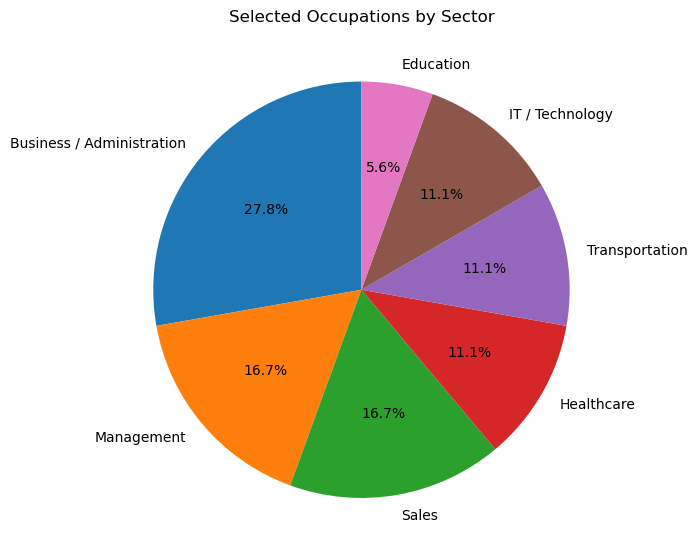

In [51]:
# Visualize selected occupations by sector

sector_counts = (
    final_summary["Sector"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    sector_counts,
    labels=sector_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Selected Occupations by Sector"
)

plt.tight_layout()

plt.savefig(
    FIGURES /
    "Selected_Occupations_by_Sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
selected_df.to_csv(
    "selected_occupations.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


## Final Occupation Selection

Fifteen occupations were selected based on posting frequency, labour-market relevance, and sufficient observations for statistical analysis.

The selected occupations span multiple sectors, including technology, business, administration, management, sales, transportation, education, and healthcare. Each occupation contains approximately 100 or more job postings, providing adequate sample sizes for descriptive analysis, diagnostic analysis, and subsequent predictive modelling.

This selected occupation set forms the analytical scope for the Week 3 diagnostic labour-market analysis.